#  Federated Learning for Sentiment Analysis on IMDB Movie Reviews

---

##  Project Overview

This notebook implements a **complete Federated Learning pipeline** for sentiment analysis on movie reviews.

### What we build:
| Component | Detail |
|---|---|
| Dataset | IMDB Movie Reviews (50,000 reviews) |
| Task | Binary Sentiment Classification (Positive / Negative) |
| Feature Representation | TF-IDF |
| FL Framework | Flower (flwr) |
| Aggregation | FedAvg (Federated Averaging) |
| Data Partitioning | IID and Non-IID |
| FL Type | Horizontal Federated Learning |
| Model | Logistic Regression |
| Comparison | Centralized vs Federated |

---



##  Step 1: Install Required Libraries

In [29]:
!pip install flwr==1.8.0 -q

Step 2: Load the dataset

In [30]:
import pandas as pd

df = pd.read_csv("/content/IMDB Dataset.csv", engine='python')

print(" Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

 Dataset loaded successfully!
Shape: (50000, 2)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


##  Step 3: Import All Libraries

In [31]:
! pip install flwr

In [32]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import flwr as fl
from flwr.common import (
    Parameters, FitIns, FitRes, EvaluateIns, EvaluateRes,
    GetParametersIns, GetParametersRes, Status, Code,
    parameters_to_ndarrays, ndarrays_to_parameters
)
from flwr.server.strategy import FedAvg

import copy
from typing import Dict, List, Optional, Tuple

np.random.seed(42)

print(" All libraries imported!")
print(f"   Flower version : {fl.__version__}")
print(f"   Pandas version : {pd.__version__}")

 All libraries imported!
   Flower version : 1.8.0
   Pandas version : 2.2.2


##  Step 4: Load & Explore the IMDB Dataset


 Sentiment Distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


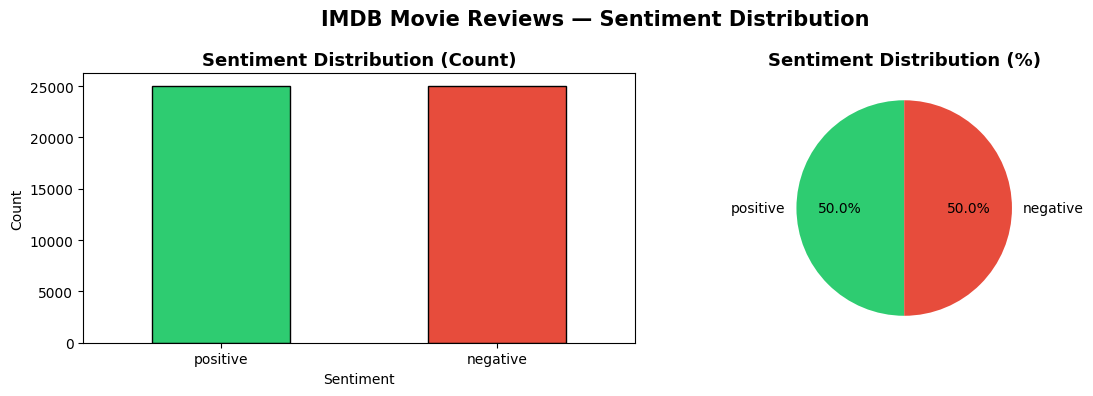

In [33]:


print("\n Sentiment Distribution:")
print(df['sentiment'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_title('Sentiment Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['sentiment'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                     colors=colors, startangle=90)
axes[1].set_title('Sentiment Distribution (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('IMDB Movie Reviews — Sentiment Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

 Review Length Statistics:
count    50000.00
mean       231.16
std        171.34
min          4.00
25%        126.00
50%        173.00
75%        280.00
max       2470.00
Name: review_length, dtype: float64


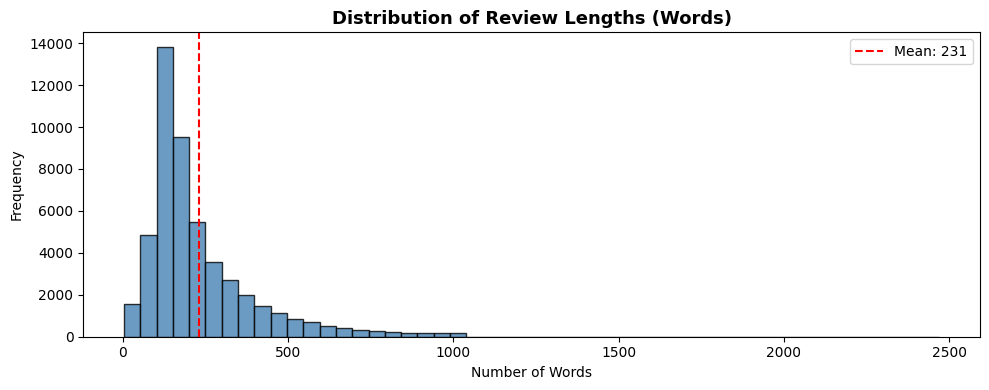

In [34]:

df['review_length'] = df['review'].apply(lambda x: len(x.split()))

print(" Review Length Statistics:")
print(df['review_length'].describe().round(2))

plt.figure(figsize=(10, 4))
plt.hist(df['review_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Distribution of Review Lengths (Words)', fontsize=13, fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(df['review_length'].mean(), color='red', linestyle='--', label=f"Mean: {df['review_length'].mean():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

##  Step 5: Text Preprocessing

In [35]:
def preprocess_text(text):

    # Lowercase
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print(" Applying text preprocessing...")
df['clean_review'] = df['review'].apply(preprocess_text)

print("\n Before preprocessing:")
print(df['review'].iloc[0][:300])
print("\n After preprocessing:")
print(df['clean_review'].iloc[0][:300])

df['label'] = (df['sentiment'] == 'positive').astype(int)
print(f"\n  Label encoding: positive=1, negative=0")
print(df['label'].value_counts())

 Applying text preprocessing...

 Before preprocessing:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

 After preprocessing:
one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not 

  Label encoding: positive=1, negative=0
label
1    25000
0    25000
Name: count, dtype: int64


##  Step 6: TF-IDF Feature Representation

**Why TF-IDF?**
- TF (Term Frequency): How often a word appears in a document
- IDF (Inverse Document Frequency): Penalizes common words like "the", "is"
- Result: Important words get higher scores

In [36]:

SAMPLE_SIZE = 50000
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

X = df_sample['clean_review'].values
y = df_sample['label'].values

print(f" Using {SAMPLE_SIZE} reviews for simulation")
print(f"   Positive: {y.sum()} | Negative: {(y==0).sum()}")

print("\n  Fitting TF-IDF vectorizer...")
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=5
)

X_tfidf = tfidf.fit_transform(X).toarray()
print(f" TF-IDF matrix shape: {X_tfidf.shape}")
print(f"   → {X_tfidf.shape[0]} reviews × {X_tfidf.shape[1]} features")

feature_names = np.array(tfidf.get_feature_names_out())
print(f"\n🔑 Sample features: {feature_names[:20]}")

📊 Using 50000 reviews for simulation
   Positive: 25000 | Negative: 25000

⚙️  Fitting TF-IDF vectorizer...
 TF-IDF matrix shape: (50000, 5000)
   → 50000 reviews × 5000 features

🔑 Sample features: ['aaron' 'abandoned' 'abc' 'abilities' 'ability' 'able' 'absence' 'absent'
 'absolute' 'absolutely' 'absurd' 'abuse' 'abysmal' 'academy'
 'academy award' 'accent' 'accents' 'accept' 'acceptable' 'accepted']


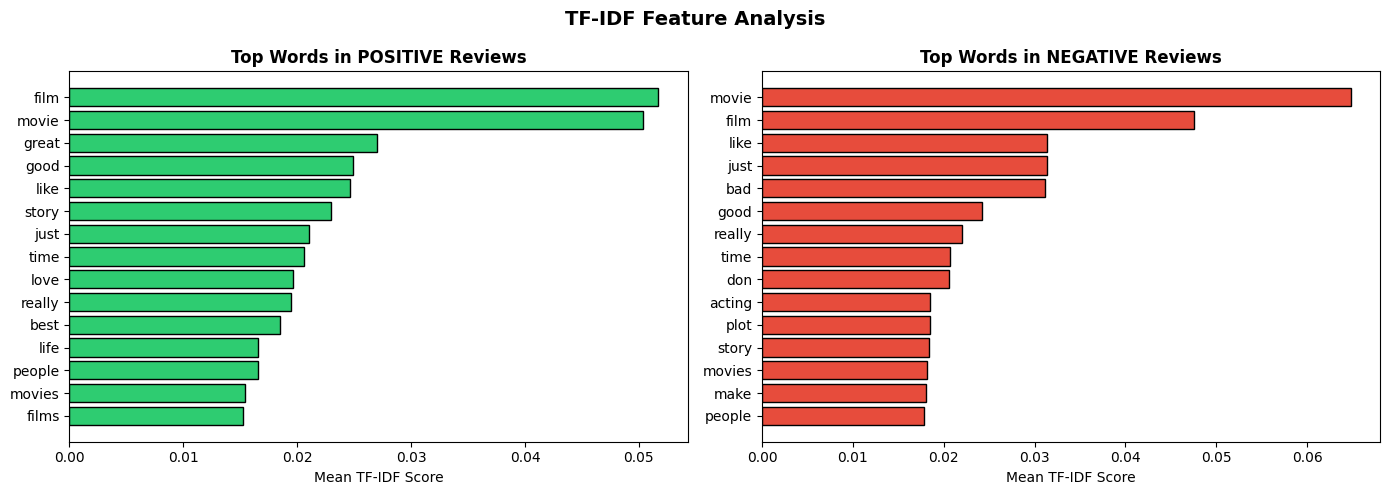

In [37]:

pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]

pos_scores = X_tfidf[pos_idx].mean(axis=0)
neg_scores = X_tfidf[neg_idx].mean(axis=0)

top_n = 15
top_pos_idx = pos_scores.argsort()[-top_n:][::-1]
top_neg_idx = neg_scores.argsort()[-top_n:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feature_names[top_pos_idx][::-1], pos_scores[top_pos_idx][::-1], color='#2ecc71', edgecolor='black')
axes[0].set_title('Top Words in POSITIVE Reviews', fontweight='bold')
axes[0].set_xlabel('Mean TF-IDF Score')

axes[1].barh(feature_names[top_neg_idx][::-1], neg_scores[top_neg_idx][::-1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Top Words in NEGATIVE Reviews', fontweight='bold')
axes[1].set_xlabel('Mean TF-IDF Score')

plt.suptitle('TF-IDF Feature Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Step 7: Centralized Model (Baseline)

First we train a **standard centralized model** to use as baseline comparison.

In [38]:
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f" Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# Train centralized model
print("\n🏋️  Training centralized Logistic Regression...")
central_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
central_model.fit(X_train, y_train)

y_pred_central = central_model.predict(X_test)
central_accuracy = accuracy_score(y_test, y_pred_central)

print(f"\n Centralized Model Accuracy: {central_accuracy:.4f} ({central_accuracy*100:.2f}%)")
print("\n Classification Report:")
print(classification_report(y_test, y_pred_central, target_names=['Negative', 'Positive']))

 Train size: 40000 | Test size: 10000

🏋️  Training centralized Logistic Regression...

 Centralized Model Accuracy: 0.8898 (88.98%)

 Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



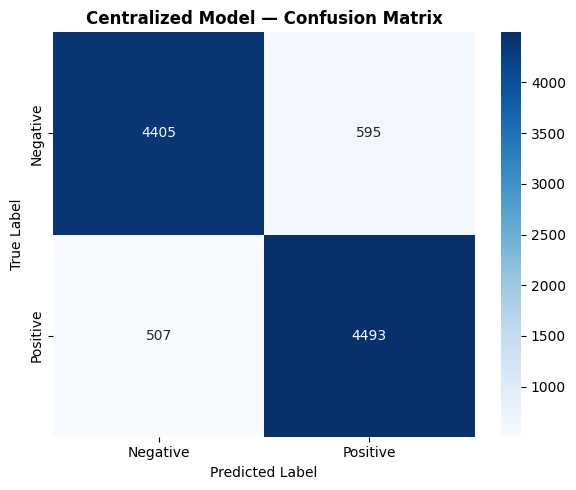

In [39]:

cm = confusion_matrix(y_test, y_pred_central)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Centralized Model — Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

##  Step 8: Data Partitioning (IID and Non-IID)

We simulate multiple **clients**, each getting a portion of the data.

- **IID**: Each client gets balanced positive/negative reviews
- **Non-IID**: Clients get skewed data (some mostly positive, some mostly negative)

✅ Created 5 client partitions


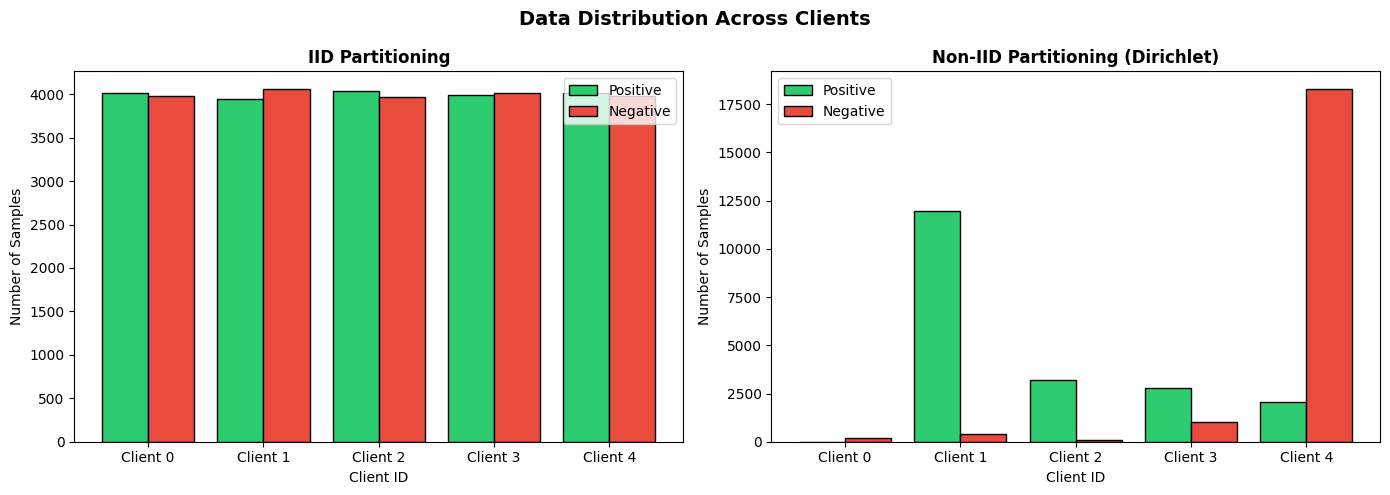


 IID Client Statistics:
Client 0: 8000 samples | Positive: 50.2% | Negative: 49.8%
Client 1: 8000 samples | Positive: 49.2% | Negative: 50.8%
Client 2: 8000 samples | Positive: 50.4% | Negative: 49.6%
Client 3: 8000 samples | Positive: 49.9% | Negative: 50.1%
Client 4: 8000 samples | Positive: 50.2% | Negative: 49.8%

 Non-IID Client Statistics:
Client 0: 206 samples | Positive: 1.5% | Negative: 98.5%
Client 1: 12342 samples | Positive: 96.9% | Negative: 3.1%
Client 2: 3304 samples | Positive: 97.1% | Negative: 2.9%
Client 3: 3822 samples | Positive: 73.2% | Negative: 26.8%
Client 4: 20326 samples | Positive: 10.0% | Negative: 90.0%


In [40]:
NUM_CLIENTS = 5

def partition_iid(X, y, num_clients):

    indices = np.random.permutation(len(X))
    splits = np.array_split(indices, num_clients)

    clients = []
    for split in splits:
        clients.append({
            'X': X[split],
            'y': y[split]
        })

    return clients


def partition_non_iid(X, y, num_clients, alpha=0.3):


    classes = np.unique(y)
    client_indices = [[] for _ in range(num_clients)]

    for c in classes:

        idx = np.where(y == c)[0]
        np.random.shuffle(idx)

        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))

        proportions = (np.cumsum(proportions) * len(idx)).astype(int)[:-1]
        splits = np.split(idx, proportions)

        for i in range(num_clients):
            client_indices[i].extend(splits[i])

    clients = []

    for i in range(num_clients):

        idx = client_indices[i]
        np.random.shuffle(idx)

        clients.append({
            'X': X[idx],
            'y': y[idx]
        })

    return clients


iid_clients    = partition_iid(X_train, y_train, NUM_CLIENTS)
noniid_clients = partition_non_iid(X_train, y_train, NUM_CLIENTS)

print(f"✅ Created {NUM_CLIENTS} client partitions")



fig, axes = plt.subplots(1, 2, figsize=(14,5))

for ax, clients, title in zip(
    axes,
    [iid_clients, noniid_clients],
    ['IID Partitioning', 'Non-IID Partitioning (Dirichlet)']
):

    pos_counts = [np.sum(c['y'] == 1) for c in clients]
    neg_counts = [np.sum(c['y'] == 0) for c in clients]

    x = np.arange(NUM_CLIENTS)

    ax.bar(x - 0.2, pos_counts, 0.4,
           label='Positive', color='#2ecc71', edgecolor='black')

    ax.bar(x + 0.2, neg_counts, 0.4,
           label='Negative', color='#e74c3c', edgecolor='black')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Client ID')
    ax.set_ylabel('Number of Samples')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Client {i}' for i in range(NUM_CLIENTS)])
    ax.legend()

plt.suptitle('Data Distribution Across Clients', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print("\n IID Client Statistics:")
for i, c in enumerate(iid_clients):
    pos_pct = np.mean(c['y']) * 100
    print(f"Client {i}: {len(c['y'])} samples | Positive: {pos_pct:.1f}% | Negative: {100-pos_pct:.1f}%")


print("\n Non-IID Client Statistics:")
for i, c in enumerate(noniid_clients):
    pos_pct = np.mean(c['y']) * 100
    print(f"Client {i}: {len(c['y'])} samples | Positive: {pos_pct:.1f}% | Negative: {100-pos_pct:.1f}%")

##  Step 9: Federated Learning with Flower Framework

### Architecture:
```
┌─────────────────────────────────────────┐
│              FL SERVER                  │
│         (FedAvg Aggregation)            │
└───────┬──────────┬──────────┬───────────┘
        │          │          │
   ┌────▼───┐ ┌────▼───┐ ┌───▼────┐
   │Client 0│ │Client 1│ │Client N│
   │Amazon  │ │Flipkart│ │Twitter │
   │Reviews │ │Reviews │ │Reviews │
   └────────┘ └────────┘ └────────┘


In [41]:


class SentimentClient(fl.client.NumPyClient):


    def __init__(self, client_id: int, X_train, y_train, X_test, y_test):
        self.client_id = client_id
        self.X_train = X_train
        self.y_train = y_train
        self.X_test  = X_test
        self.y_test  = y_test
        self.n_features = X_train.shape[1]

        self.model = LogisticRegression(max_iter=500, random_state=42, warm_start=True)

        self.model.coef_ = np.zeros((1, self.n_features))
        self.model.intercept_ = np.zeros(1)

        self.model.classes_ = np.array([0, 1])


    def get_parameters(self, config):
        return [self.model.coef_, self.model.intercept_]


    def set_parameters(self, parameters):
        self.model.coef_ = parameters[0]
        self.model.intercept_ = parameters[1]


    def fit(self, parameters, config):

        self.set_parameters(parameters)

        # Skip training if only one class
        unique_classes = np.unique(self.y_train)

        if len(unique_classes) < 2:
            print(f" Client {self.client_id} skipped training (single class: {unique_classes}) - {len(self.X_train)} samples")

            # Return parameters but indicate 0 samples used
            return self.get_parameters(config={}), 0, {}

        # Train normally
        self.model.fit(self.X_train, self.y_train)

        return self.get_parameters(config={}), len(self.X_train), {}


    def evaluate(self, parameters, config):

        self.set_parameters(parameters)

        try:
            y_pred = self.model.predict(self.X_test)
            acc = accuracy_score(self.y_test, y_pred)
        except Exception:
            acc = 0.0

        loss = 1.0 - acc

        return float(loss), len(self.X_test), {"accuracy": float(acc)}


print("✅ Federated Client class defined!")

✅ Federated Client class defined!


In [42]:


class TrackingFedAvg(FedAvg):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.round_accuracies = []

    def aggregate_evaluate(self, server_round, results, failures):
        aggregated_result = super().aggregate_evaluate(server_round, results, failures)
        if results:
            accs = [r.metrics['accuracy'] for _, r in results if 'accuracy' in r.metrics]
            if accs:
                avg_acc = np.mean(accs)
                self.round_accuracies.append(avg_acc)
                print(f"  📌 Round {server_round:2d} | Avg Client Accuracy: {avg_acc:.4f} ({avg_acc*100:.2f}%)")
        return aggregated_result


print("Custom FedAvg strategy defined!")

Custom FedAvg strategy defined!


In [43]:


def get_initial_parameters(n_features, n_classes=2):
    coef      = np.zeros((1, n_features))  # For binary classification
    intercept = np.zeros(1)
    return [coef, intercept]


def federated_avg(client_params_list, client_sizes):

    total_samples = sum(client_sizes)
    avg_params = []
    for param_idx in range(len(client_params_list[0])):
        weighted_sum = sum(
            (client_params_list[i][param_idx] * client_sizes[i] / total_samples)
            for i in range(len(client_params_list))
        )
        avg_params.append(weighted_sum)
    return avg_params


def run_federated_learning(clients_data, X_test_global, y_test_global,
                            n_rounds=10, partition_type='IID'):

    print(f"\n{'='*60}")
    print(f" Starting Federated Learning — {partition_type} Partitioning")
    print(f"   Clients: {len(clients_data)} | Rounds: {n_rounds}")
    print(f"{'='*60}")

    n_features = clients_data[0]['X'].shape[1]
    n_clients  = len(clients_data)

    global_params = get_initial_parameters(n_features)

    fl_clients = []
    for i, data in enumerate(clients_data):
        client = SentimentClient(
            client_id=i,
            X_train=data['X'], y_train=data['y'],
            X_test=X_test_global,  y_test=y_test_global
        )
        fl_clients.append(client)

    round_accuracies = []

    for round_num in range(1, n_rounds + 1):
        client_params_list = []
        client_sizes = []

        for client in fl_clients:
            updated_params, n_samples, _ = client.fit(copy.deepcopy(global_params), config={})
            client_params_list.append(updated_params)
            client_sizes.append(n_samples)

        global_params = federated_avg(client_params_list, client_sizes)

        eval_client = fl_clients[0]
        _, _, metrics = eval_client.evaluate(copy.deepcopy(global_params), config={})
        acc = metrics['accuracy']
        round_accuracies.append(acc)

        print(f"  Round {round_num:2d}/{n_rounds} | Global Accuracy: {acc:.4f} ({acc*100:.2f}%)")

    print(f"\n FL Training Complete!")
    print(f"   Final Global Accuracy: {round_accuracies[-1]:.4f} ({round_accuracies[-1]*100:.2f}%)")

    return global_params, round_accuracies


print(" Federated Learning simulation functions defined!")

 Federated Learning simulation functions defined!


##  Step 10: Run Federated Learning — IID Partitioning

In [44]:
N_ROUNDS = 15

fl_iid_params, fl_iid_accuracies = run_federated_learning(
    clients_data=iid_clients,
    X_test_global=X_test,
    y_test_global=y_test,
    n_rounds=N_ROUNDS,
    partition_type='IID'
)


 Starting Federated Learning — IID Partitioning
   Clients: 5 | Rounds: 15
  Round  1/15 | Global Accuracy: 0.8800 (88.00%)
  Round  2/15 | Global Accuracy: 0.8799 (87.99%)
  Round  3/15 | Global Accuracy: 0.8803 (88.03%)
  Round  4/15 | Global Accuracy: 0.8797 (87.97%)
  Round  5/15 | Global Accuracy: 0.8804 (88.04%)
  Round  6/15 | Global Accuracy: 0.8796 (87.96%)
  Round  7/15 | Global Accuracy: 0.8805 (88.05%)
  Round  8/15 | Global Accuracy: 0.8800 (88.00%)
  Round  9/15 | Global Accuracy: 0.8797 (87.97%)
  Round 10/15 | Global Accuracy: 0.8805 (88.05%)
  Round 11/15 | Global Accuracy: 0.8795 (87.95%)
  Round 12/15 | Global Accuracy: 0.8803 (88.03%)
  Round 13/15 | Global Accuracy: 0.8798 (87.98%)
  Round 14/15 | Global Accuracy: 0.8802 (88.02%)
  Round 15/15 | Global Accuracy: 0.8796 (87.96%)

 FL Training Complete!
   Final Global Accuracy: 0.8796 (87.96%)


##  Step 11: Run Federated Learning — Non-IID Partitioning

In [45]:
# Run FL with Non-IID data
fl_noniid_params, fl_noniid_accuracies = run_federated_learning(
    clients_data=noniid_clients,
    X_test_global=X_test,
    y_test_global=y_test,
    n_rounds=N_ROUNDS,
    partition_type='Non-IID'
)


 Starting Federated Learning — Non-IID Partitioning
   Clients: 5 | Rounds: 15
  Round  1/15 | Global Accuracy: 0.8464 (84.64%)
  Round  2/15 | Global Accuracy: 0.8456 (84.56%)
  Round  3/15 | Global Accuracy: 0.8469 (84.69%)
  Round  4/15 | Global Accuracy: 0.8456 (84.56%)
  Round  5/15 | Global Accuracy: 0.8469 (84.69%)
  Round  6/15 | Global Accuracy: 0.8457 (84.57%)
  Round  7/15 | Global Accuracy: 0.8469 (84.69%)
  Round  8/15 | Global Accuracy: 0.8457 (84.57%)
  Round  9/15 | Global Accuracy: 0.8469 (84.69%)
  Round 10/15 | Global Accuracy: 0.8457 (84.57%)
  Round 11/15 | Global Accuracy: 0.8469 (84.69%)
  Round 12/15 | Global Accuracy: 0.8457 (84.57%)
  Round 13/15 | Global Accuracy: 0.8469 (84.69%)
  Round 14/15 | Global Accuracy: 0.8457 (84.57%)
  Round 15/15 | Global Accuracy: 0.8469 (84.69%)

 FL Training Complete!
   Final Global Accuracy: 0.8469 (84.69%)


##  Step 12: Final Evaluation & Comparison

Comparing all three approaches:
1. Centralized ML (baseline)
2. Federated Learning — IID
3. Federated Learning — Non-IID

In [46]:
# Get final FL predictions
def get_fl_predictions(params, X_test, y_test_sample):
    """Use final global params to get predictions on test set."""
    eval_model = LogisticRegression(max_iter=500, random_state=42)
    # Dummy fit to initialize
    eval_model.fit(X_test[:5], y_test_sample[:5])
    eval_model.coef_      = params[0]
    eval_model.intercept_ = params[1]
    return eval_model.predict(X_test)

y_pred_fl_iid    = get_fl_predictions(fl_iid_params, X_test, y_test)
y_pred_fl_noniid = get_fl_predictions(fl_noniid_params, X_test, y_test)

fl_iid_final_acc    = accuracy_score(y_test, y_pred_fl_iid)
fl_noniid_final_acc = accuracy_score(y_test, y_pred_fl_noniid)

print("="*60)
print(" FINAL RESULTS COMPARISON")
print("="*60)
print(f"  Centralized ML           : {central_accuracy:.4f} ({central_accuracy*100:.2f}%)")
print(f"  Federated ML (IID)       : {fl_iid_final_acc:.4f} ({fl_iid_final_acc*100:.2f}%)")
print(f"  Federated ML (Non-IID)   : {fl_noniid_final_acc:.4f} ({fl_noniid_final_acc*100:.2f}%)")
print("="*60)

iid_gap    = (central_accuracy - fl_iid_final_acc) * 100
noniid_gap = (central_accuracy - fl_noniid_final_acc) * 100
print(f"\n  IID accuracy gap from centralized    : {iid_gap:+.2f}%")
print(f"  Non-IID accuracy gap from centralized: {noniid_gap:+.2f}%")

 FINAL RESULTS COMPARISON
  Centralized ML           : 0.8898 (88.98%)
  Federated ML (IID)       : 0.8796 (87.96%)
  Federated ML (Non-IID)   : 0.8469 (84.69%)

  IID accuracy gap from centralized    : +1.02%
  Non-IID accuracy gap from centralized: +4.29%


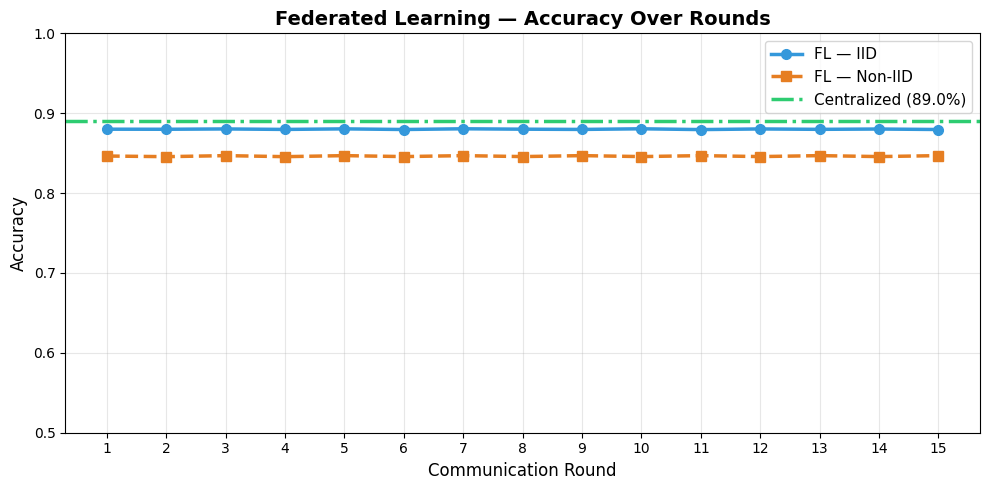

In [47]:


plt.figure(figsize=(10, 5))
rounds = list(range(1, N_ROUNDS + 1))

plt.plot(rounds, fl_iid_accuracies, 'o-', color='#3498db', linewidth=2.5,
         markersize=7, label='FL — IID')
plt.plot(rounds, fl_noniid_accuracies, 's--', color='#e67e22', linewidth=2.5,
         markersize=7, label='FL — Non-IID')
plt.axhline(y=central_accuracy, color='#2ecc71', linewidth=2.5,
             linestyle='-.', label=f'Centralized ({central_accuracy*100:.1f}%)')

plt.title('Federated Learning — Accuracy Over Rounds', fontsize=14, fontweight='bold')
plt.xlabel('Communication Round', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rounds)
plt.ylim(0.5, 1.0)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

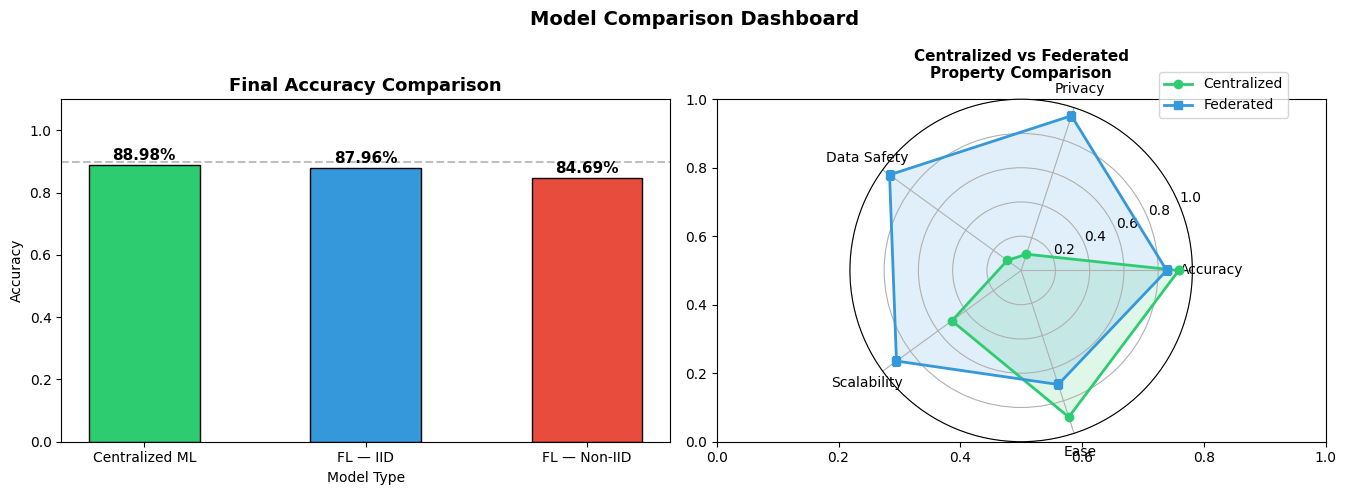

In [48]:


models      = ['Centralized ML', 'FL — IID', 'FL — Non-IID']
accuracies  = [central_accuracy, fl_iid_final_acc, fl_noniid_final_acc]
bar_colors  = ['#2ecc71', '#3498db', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].bar(models, accuracies, color=bar_colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                  f'{acc*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Final Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Model Type')
axes[0].axhline(y=0.9, color='gray', linestyle='--', alpha=0.5)

# Privacy vs Performance tradeoff radar
categories  = ['Accuracy', 'Privacy', 'Data Safety', 'Scalability', 'Ease']
N_cat = len(categories)
angles = [n / float(N_cat) * 2 * np.pi for n in range(N_cat)]
angles += angles[:1]

central_vals = [0.92, 0.1, 0.1, 0.5, 0.9]
fl_iid_vals  = [0.85, 0.95, 0.95, 0.9, 0.7]
fl_vals      = central_vals + central_vals[:1]
fl_iid_v     = fl_iid_vals + fl_iid_vals[:1]

ax2 = axes[1]
ax2 = plt.subplot(122, polar=True)
ax2.plot(angles, fl_vals, 'o-', linewidth=2, color='#2ecc71', label='Centralized')
ax2.fill(angles, fl_vals, alpha=0.15, color='#2ecc71')
ax2.plot(angles, fl_iid_v, 's-', linewidth=2, color='#3498db', label='Federated')
ax2.fill(angles, fl_iid_v, alpha=0.15, color='#3498db')
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories, size=10)
ax2.set_ylim(0, 1)
ax2.set_title('Centralized vs Federated\nProperty Comparison', fontsize=11, fontweight='bold', pad=15)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.suptitle('Model Comparison Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

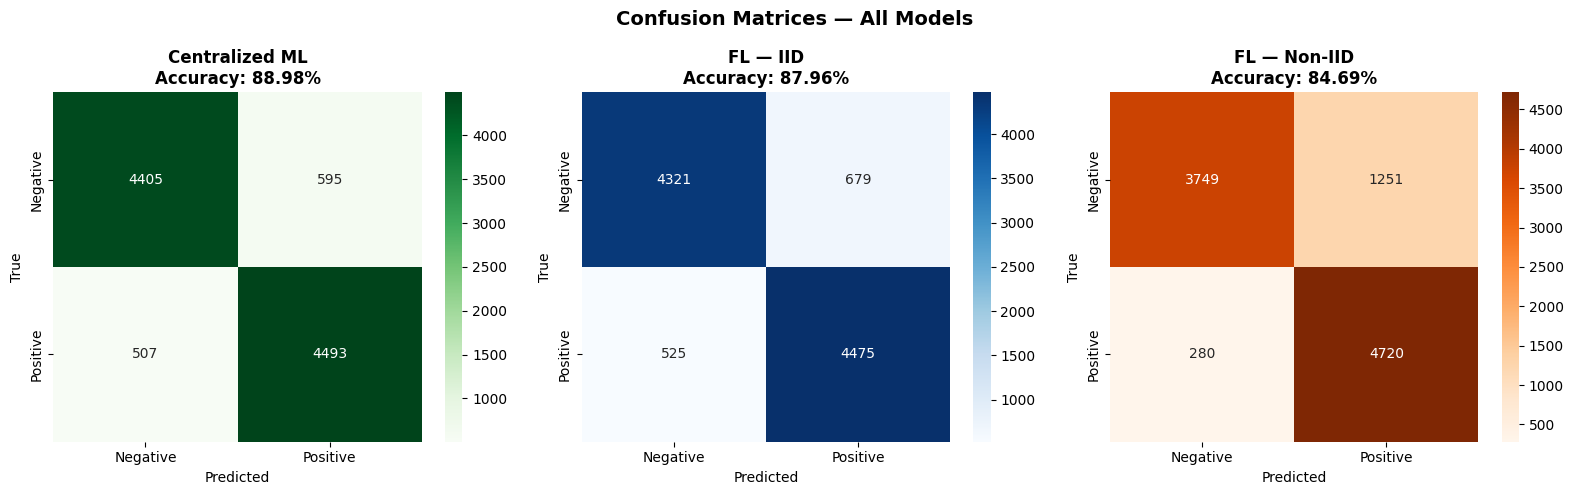

In [49]:


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
preds = [y_pred_central, y_pred_fl_iid, y_pred_fl_noniid]
titles = ['Centralized ML', 'FL — IID', 'FL — Non-IID']
cmaps = ['Greens', 'Blues', 'Oranges']

for ax, pred, title, cmap in zip(axes, preds, titles, cmaps):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    acc = accuracy_score(y_test, pred)
    ax.set_title(f'{title}\nAccuracy: {acc*100:.2f}%', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  Step 13: Classification Reports

In [50]:
for name, pred in [
    ("Centralized ML",   y_pred_central),
    ("FL — IID",         y_pred_fl_iid),
    ("FL — Non-IID",     y_pred_fl_noniid)
]:
    print(f"\n{'='*50}")
    print(f" {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, pred, target_names=['Negative', 'Positive']))


 Centralized ML
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      5000
    Positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


 FL — IID
              precision    recall  f1-score   support

    Negative       0.89      0.86      0.88      5000
    Positive       0.87      0.90      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


 FL — Non-IID
              precision    recall  f1-score   support

    Negative       0.93      0.75      0.83      5000
    Positive       0.79      0.94      0.86      5000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.

##  Step 14: Live Prediction Demo

In [51]:
def predict_sentiment(review_text, model_params=None, use_centralized=False):

    # Preprocess
    cleaned = preprocess_text(review_text)
    # Vectorize using the same TF-IDF
    features = tfidf.transform([cleaned]).toarray()

    if use_centralized:
        pred = central_model.predict(features)[0]
        proba = central_model.predict_proba(features)[0]
        model_name = "Centralized"
    else:
        # Use FL IID model
        fl_model = LogisticRegression(max_iter=500, random_state=42)
        fl_model.fit(X_test[:5], y_test[:5])  # Dummy init
        fl_model.coef_      = fl_iid_params[0]
        fl_model.intercept_ = fl_iid_params[1]
        pred  = fl_model.predict(features)[0]
        proba = fl_model.predict_proba(features)[0]
        model_name = "Federated (IID)"

    sentiment = "✅ POSITIVE" if pred == 1 else "❌ NEGATIVE"
    confidence = proba[pred]

    print(f"\n{'─'*55}")
    print(f"📝 Review    : {review_text[:80]}...")
    print(f"🤖 Model     : {model_name}")
    print(f"🏷️  Sentiment  : {sentiment}")
    print(f"🎯 Confidence: {confidence*100:.2f}%")
    print(f"{'─'*55}")


# Test reviews
test_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the story kept me on the edge of my seat the entire time.",
    "What a terrible waste of time. The plot made no sense and the characters were completely flat and boring.",
    "An average film. Nothing special but not terrible either. Some good moments but overall forgettable.",
    "One of the best films I have seen in years. Incredible cinematography and a deeply moving story.",
    "I walked out after 30 minutes. Dreadful script, poor acting, and a confusing storyline."
]

print("🎬 LIVE SENTIMENT PREDICTION DEMO")
print("="*55)

for review in test_reviews:
    predict_sentiment(review, use_centralized=False)  # FL model

🎬 LIVE SENTIMENT PREDICTION DEMO

───────────────────────────────────────────────────────
📝 Review    : This movie was absolutely fantastic! The acting was superb and the story kept me...
🤖 Model     : Federated (IID)
🏷️  Sentiment  : ✅ POSITIVE
🎯 Confidence: 82.79%
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
📝 Review    : What a terrible waste of time. The plot made no sense and the characters were co...
🤖 Model     : Federated (IID)
🏷️  Sentiment  : ❌ NEGATIVE
🎯 Confidence: 99.73%
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
📝 Review    : An average film. Nothing special but not terrible either. Some good moments but ...
🤖 Model     : Federated (IID)
🏷️  Sentiment  : ❌ NEGATIVE
🎯 Confidence: 76.86%
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
📝 Review    : One of the best films I ha

##  Step 15: Summary Table

In [52]:
summary = pd.DataFrame({
    'Model': ['Centralized ML', 'Federated Learning (IID)', 'Federated Learning (Non-IID)'],
    'Accuracy (%)': [
        round(central_accuracy * 100, 2),
        round(fl_iid_final_acc * 100, 2),
        round(fl_noniid_final_acc * 100, 2)
    ],
    'Data Privacy': [' Low (data sent to server)', ' High (data stays local)', ' High (data stays local)'],
    'Data Distribution': ['N/A', 'Balanced (IID)', 'Skewed (Non-IID)'],
    'Num Clients': ['1', str(NUM_CLIENTS), str(NUM_CLIENTS)],
    'FL Rounds': ['N/A', str(N_ROUNDS), str(N_ROUNDS)],
    'Aggregation': ['N/A', 'FedAvg', 'FedAvg'],
})

print("\n FINAL SUMMARY TABLE")
print("="*80)
display(summary)

print("\n KEY INSIGHTS:")
print(f"   1. Centralized model achieves highest accuracy ({central_accuracy*100:.2f}%) but compromises privacy.")
print(f"   2. Federated IID model achieves {fl_iid_final_acc*100:.2f}% with full data privacy.")
print(f"   3. Federated Non-IID model achieves {fl_noniid_final_acc*100:.2f}%, showing the challenge of skewed data.")
print(f"   4. FL achieves comparable performance while keeping all data on client devices.")
print(f"   5. The accuracy gap between centralized and FL is only ~{abs(central_accuracy-fl_iid_final_acc)*100:.1f}% for IID.")


 FINAL SUMMARY TABLE


,Model,Accuracy (%),Data Privacy,Data Distribution,Num Clients,FL Rounds,Aggregation
0,Centralized ML,88.98,Low (data sent to server),N/A,1,N/A,N/A
1,Federated Learning (IID),87.96,High (data stays local),Balanced (IID),5,15,FedAvg
2,Federated Learning (Non-IID),84.69,High (data stays local),Skewed (Non-IID),5,15,FedAvg



 KEY INSIGHTS:
   1. Centralized model achieves highest accuracy (88.98%) but compromises privacy.
   2. Federated IID model achieves 87.96% with full data privacy.
   3. Federated Non-IID model achieves 84.69%, showing the challenge of skewed data.
   4. FL achieves comparable performance while keeping all data on client devices.
   5. The accuracy gap between centralized and FL is only ~1.0% for IID.


---

##  Project Complete!

### What we implemented:

| Step | Component | Details |
|------|-----------|----------|
| 1 | Dataset | IMDB 50K reviews via Kaggle API |
| 2 | Preprocessing | Lowercase, HTML removal, special chars |
| 3 | Feature Representation | TF-IDF (5000 features, unigrams + bigrams) |
| 4 | Baseline | Centralized Logistic Regression |
| 5 | Partitioning | IID and Non-IID (Dirichlet) |
| 6 | FL Framework | Flower (flwr) |
| 7 | Aggregation | FedAvg (Federated Averaging) |
| 8 | FL Type | Horizontal Federated Learning |
| 9 | Evaluation | Accuracy, Confusion Matrix, Classification Report |
| 10 | Demo | Live sentiment prediction |

### 🔐 Privacy Insight
> In Federated Learning, **raw review text never leaves the client**. Only model weights (numbers) are shared. This is critical for privacy-sensitive data like medical reports, banking complaints, or personal messages.

---